In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/var/folders/k_/4mk26lc17c1_f33q7r45t8f80000gn/T/ipykernel_29693/1304978644.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


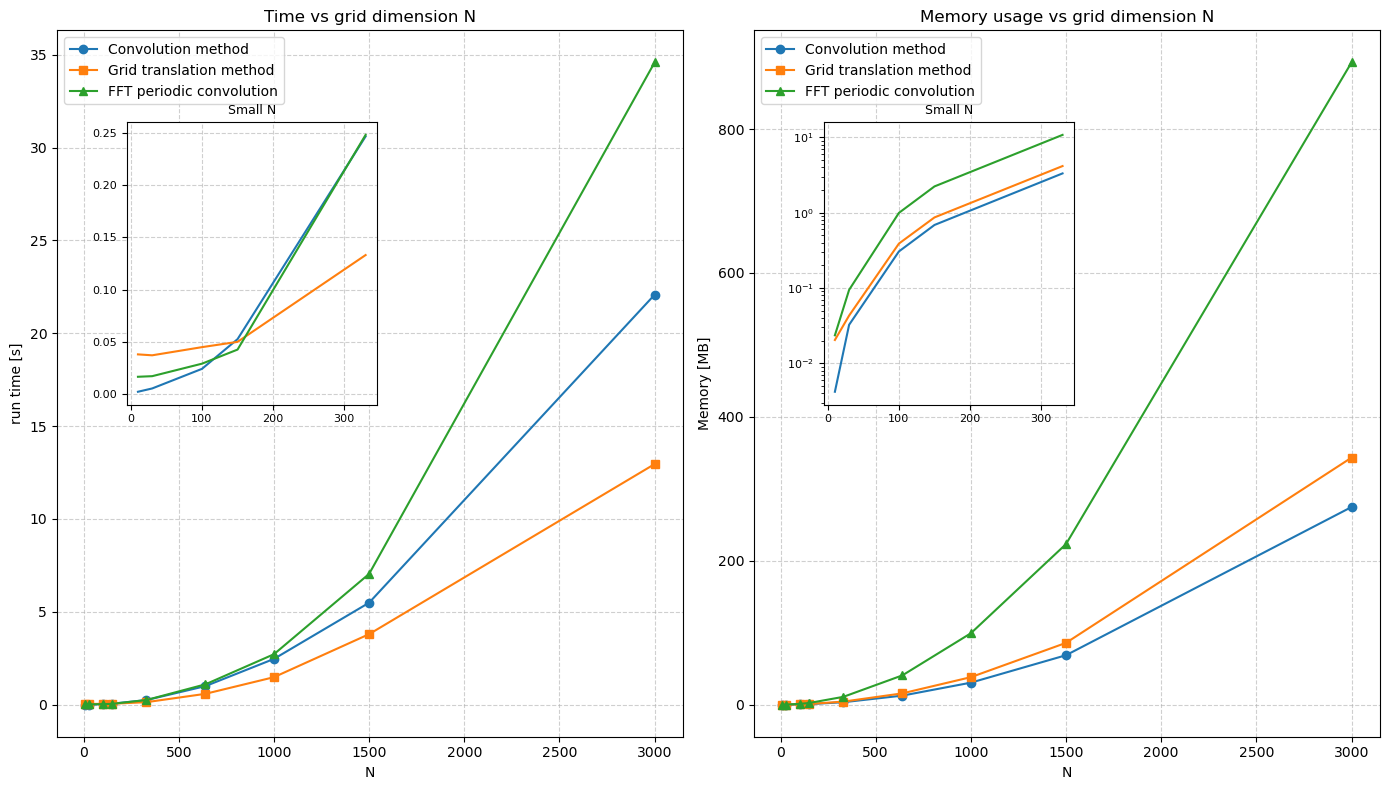

In [2]:
df_conv = pd.read_csv('convolution_TM_data.csv')
df_grid = pd.read_csv('grid_TM_data.csv')
df_fft  = pd.read_csv('fft_periodic_convolution_TM_data.csv')

# Conversione memoria in MB
df_conv['peak_MB'] = df_conv['peak_kB'] / 1024
df_grid['peak_MB'] = df_grid['peak_kB'] / 1024
df_fft['peak_MB']  = df_fft['peak_kB'] / 1024

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# ---------- TIME PLOT ----------
ax1.set_title('Time vs grid dimension N')

ax1.plot(df_conv['N'], df_conv['time_s'], marker='o', label='Convolution method')
ax1.plot(df_grid['N'], df_grid['time_s'], marker='s', label='Grid translation method')
ax1.plot(df_fft['N'],  df_fft['time_s'],  marker='^', label='FFT periodic convolution')

ax1.set_xlabel('N')
ax1.set_ylabel('run time [s]')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Inset: primi 5 punti
ax1_in = inset_axes(
    ax1,
    width="40%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.1, -0.12, 1, 1),
    bbox_transform=ax1.transAxes
)

ax1_in.plot(df_conv['N'][:5], df_conv['time_s'][:5])
ax1_in.plot(df_grid['N'][:5], df_grid['time_s'][:5])
ax1_in.plot(df_fft['N'][:5],  df_fft['time_s'][:5])

ax1_in.set_title('Small N', fontsize=9)
ax1_in.grid(True, linestyle='--', alpha=0.6)
ax1_in.tick_params(labelsize=8)

# ---------- MEMORY PLOT ----------
ax2.set_title('Memory usage vs grid dimension N')

ax2.plot(df_conv['N'], df_conv['peak_MB'], marker='o', label='Convolution method')
ax2.plot(df_grid['N'], df_grid['peak_MB'], marker='s', label='Grid translation method')
ax2.plot(df_fft['N'],  df_fft['peak_MB'],  marker='^', label='FFT periodic convolution')

ax2.set_xlabel('N')
ax2.set_ylabel('Memory [MB]')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Inset: primi 5 punti
ax2_in = inset_axes(
    ax2,
    width="40%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.1, -0.12, 1, 1),
    bbox_transform=ax2.transAxes
)

ax2_in.set_yscale('log')

ax2_in.plot(df_conv['N'][:5], df_conv['peak_MB'][:5])
ax2_in.plot(df_grid['N'][:5], df_grid['peak_MB'][:5])
ax2_in.plot(df_fft['N'][:5],  df_fft['peak_MB'][:5])

ax2_in.set_title('Small N', fontsize=9)
ax2_in.grid(True, linestyle='--', alpha=0.6)
ax2_in.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


As expected we find that the computational cost go as $\sim k O(N^2)$ for the grid translation method and for the convolution method while for the convolution using FFT we have $\sim O(N^2\log(N))$ since it is in 2D. In the first two cases the constant is $k=8$ for the grid method since we translate 8 grids, while for the convolution it is $k=9$ (area of the kernel). Because we have a small kernel it is not worth it to use FFT since $\log(N) > k$; this becomes convenient only for big kernels.

As for memory efficiency we have that again the first two methods use much less memory than the third one. Since they use a similar amount of memory, based on run time performance, we decide to use the grid method. In fact, for worlds of size greater than 150 (which we will use the most) we have a time performance gain. 